# MCAF Hardware-in-the-Loop (HiL) Example

This notebook demonstrates how to use **pyX2Cscope** to control and monitor a BLDC motor running
[MCAF (Motor Control Application Framework)](https://www.microchip.com/en-us/solutions/technologies/motor-control-and-drive/motorbench-development-suite)
firmware on a Microchip device.

### What this notebook does

1. Connects to the target via serial (UART)
2. Disables the hardware UI so the script has exclusive control
3. Stops any running motor
4. Ramps the motor to **700 RPM**, measures the time to reach that speed, then captures phase currents with the scope
5. Arms the scope on `velocityMeasured`, ramps to **1400 RPM**, and plots the speed ramp curve (~60 ms)
6. Captures phase currents at 1400 RPM and calculates RMS values
7. Stops the motor and returns control to the hardware UI

### Hardware used in this test

| Component | Description |
|---|---|
| [MCLV-48V-300W Inverter Board (EV18H47A)](https://www.microchip.com/en-us/development-tool/ev18h47a) | Motor control inverter board (low-voltage, up to 48 V / 300 W) |
| [dsPIC33CK Low Voltage Motor Control (LVMC) Board (EV62P66A)](https://www.microchip.com/en-us/development-tool/ev62p66a) | Digital controller board with dsPIC33CK DSC |
| ACT 42BLF02 | BLDC motor |

The firmware was generated with [MotorBench Development Suite (MCAF)](https://www.microchip.com/en-us/solutions/technologies/motor-control-and-drive/motorbench-development-suite).

### Prerequisites

- The hardware listed above, connected via USB/serial
- The matching `.elf` file for the firmware flashed on the controller board
- pyX2Cscope installed: `pip install pyx2cscope`

> **Note:** The variable names used here (`motor.apiData.velocityReference`, etc.) are specific to MCAF.
> Use `x2c_scope.list_variables()` to browse the variables available in your firmware.

## 1 — Imports

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from pyx2cscope.x2cscope import X2CScope

## 2 — Configuration

Set the serial port and the path to the ELF file for your board.

| Setting | Description |
|---|---|
| `SERIAL_PORT` | COM port on Windows (`"COM3"`) or device path on Linux/macOS (`"/dev/ttyUSB0"`). Use `"AUTO"` to let pyX2Cscope detect the port automatically. |
| `ELF_FILE` | Full path to the `.elf` file matching the firmware on your board. |

In [ ]:
SERIAL_PORT = "AUTO"          # or e.g. "COM3" / "/dev/ttyUSB0"
ELF_FILE    = r"C:\Users\M71906\Projects\pyx2c_training\mb_foc_dspic.X\dist\default\production\mb_foc_dspic.X.production.elf"   # <-- update this path

# Speed thresholds — MCAF stores speed as RPM * 10
TARGET_SPEED_1_RPM = 7000    # represents 700.0 RPM
TARGET_SPEED_2_RPM = 14000   # represents 1400.0 RPM

## 3 — Connect to the target

In [3]:
x2c_scope = X2CScope(port=SERIAL_PORT, elf_file=ELF_FILE)

device_info = x2c_scope.get_device_info()
print("Connected to:", device_info)

Connected to: {'processor_id': '__GENERIC_MICROCHIP_DSPIC__', 'uc_width': '16-bit', 'date': 'Sep132024', 'time': '1516', 'AppVer': 2048, 'dsp_state': 'Application runs on target'}


### Browse available variables (optional)

Run this cell to see all variables exposed by the firmware.

In [4]:
variables = x2c_scope.list_variables()
print(f"{len(variables)} variables available")
variables[:20]   # show first 20

19215 variables available


['app.hardwareUiEnabled',
 'app.motorDirection',
 'app.motorVelocityCommand',
 'app.motorVelocityCommandMaximum',
 'app.motorVelocityCommandMinimum',
 'bPreCleared',
 'calibOffset',
 'compilationDate.date',
 'compilationDate.date[0]',
 'compilationDate.date[10]',
 'compilationDate.date[1]',
 'compilationDate.date[2]',
 'compilationDate.date[3]',
 'compilationDate.date[4]',
 'compilationDate.date[5]',
 'compilationDate.date[6]',
 'compilationDate.date[7]',
 'compilationDate.date[8]',
 'compilationDate.date[9]',
 'compilationDate.time']

## 4 — Take control: disable hardware UI and stop the motor

In [5]:
# Disable the hardware UI so this script has exclusive control
hardware_ui_enabled = x2c_scope.get_variable("app.hardwareUiEnabled")
hardware_ui_enabled.set_value(0)
print("Hardware UI disabled")

# Stop the motor (in case it is already running)
stop_motor_request = x2c_scope.get_variable("motor.apiData.stopMotorRequest")
stop_motor_request.set_value(1)
print("Stop request sent")

Hardware UI disabled
Stop request sent


## 5 — Ramp to 700 RPM and measure time to reach speed

In [6]:
velocity_reference = x2c_scope.get_variable("motor.apiData.velocityReference")
velocity_reference.set_value(TARGET_SPEED_1_RPM)

run_motor_request = x2c_scope.get_variable("motor.apiData.runMotorRequest")
run_motor_request.set_value(1)
print(f"Motor started, target: {TARGET_SPEED_1_RPM / 10:.0f} RPM")

speed_measured = x2c_scope.get_variable("motor.apiData.velocityMeasured")
start_time = time.time()
while speed_measured.get_value() < TARGET_SPEED_1_RPM:
    time.sleep(0.05)
time_to_speed_1 = time.time() - start_time

print(f"Reached {TARGET_SPEED_1_RPM / 10:.0f} RPM in {time_to_speed_1:.2f} s")

Motor started, target: 700 RPM
Reached 700 RPM in 0.69 s


## 6 — Capture phase currents at 700 RPM with the scope

In [7]:
time.sleep(2)   # let the motor settle

phase_current_a = x2c_scope.get_variable("motor.iabc.a")
phase_current_b = x2c_scope.get_variable("motor.iabc.b")
x2c_scope.add_scope_channel(phase_current_a)
x2c_scope.add_scope_channel(phase_current_b)

x2c_scope.request_scope_data()
while not x2c_scope.is_scope_data_ready():
    time.sleep(0.1)

scope_data_1 = x2c_scope.get_scope_channel_data()
current_a_1 = np.array(scope_data_1["motor.iabc.a"])
current_b_1 = np.array(scope_data_1["motor.iabc.b"])

rms_a_1 = np.sqrt(np.mean(current_a_1 ** 2)) * 0.1
rms_b_1 = np.sqrt(np.mean(current_b_1 ** 2)) * 0.1
avg_current_1 = (rms_a_1 + rms_b_1) / 2

print(f"RMS current at {TARGET_SPEED_1_RPM / 10:.0f} RPM:  Ia={rms_a_1:.3f} A  Ib={rms_b_1:.3f} A  avg={avg_current_1:.3f} A")

RMS current at 700 RPM:  Ia=18.858 A  Ib=17.568 A  avg=18.213 A


### Plot phase currents at 700 RPM

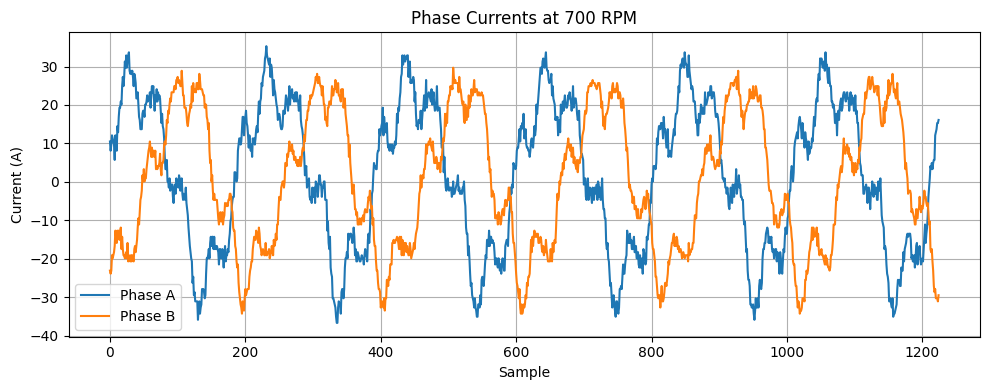

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(current_a_1 * 0.1, label="Phase A")
ax.plot(current_b_1 * 0.1, label="Phase B")
ax.set_title(f"Phase Currents at {TARGET_SPEED_1_RPM / 10:.0f} RPM")
ax.set_xlabel("Sample")
ax.set_ylabel("Current (A)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 7 — Capture speed ramp: 700 → 1400 RPM

Add `motor.apiData.velocityMeasured` as a scope channel, arm the scope, **then** command the speed
change so the ramp is captured in the buffer.  The scope window is set to cover ~100 ms
(sample time factor 0, firmware sample period ≈ 50 µs).

In [9]:
SCOPE_SAMPLE_TIME_US = 50   # firmware interrupt period in µs — adjust if needed

# Add speed as a scope channel (replaces current channels for this capture)
x2c_scope.clear_all_scope_channel()
x2c_scope.add_scope_channel(speed_measured)

# Set sample time factor (0 = every firmware tick, gives the finest resolution)
x2c_scope.set_sample_time(0)

# Compute the total scope window so we can build the time axis later
scope_window_ms = x2c_scope.get_scope_sample_time(SCOPE_SAMPLE_TIME_US)
print(f"Scope window: {scope_window_ms:.1f} ms")

# Arm the scope FIRST, then trigger the speed change
x2c_scope.request_scope_data()
velocity_reference.set_value(TARGET_SPEED_2_RPM)
print(f"Target speed changed to {TARGET_SPEED_2_RPM / 10:.0f} RPM — waiting for scope capture…")

while not x2c_scope.is_scope_data_ready():
    time.sleep(0.05)

ramp_data = x2c_scope.get_scope_channel_data()
ramp_speed_raw = np.array(ramp_data["motor.apiData.velocityMeasured"])
ramp_speed_rpm = ramp_speed_raw / 10          # convert to RPM
n_samples = len(ramp_speed_rpm)
ramp_time_ms = np.linspace(0, scope_window_ms, n_samples)

print(f"Captured {n_samples} samples over {scope_window_ms:.1f} ms")

Scope window: 122.5 ms
Target speed changed to 1400 RPM — waiting for scope capture…
Captured 2450 samples over 122.5 ms


### Plot speed ramp (700 → 1400 RPM)

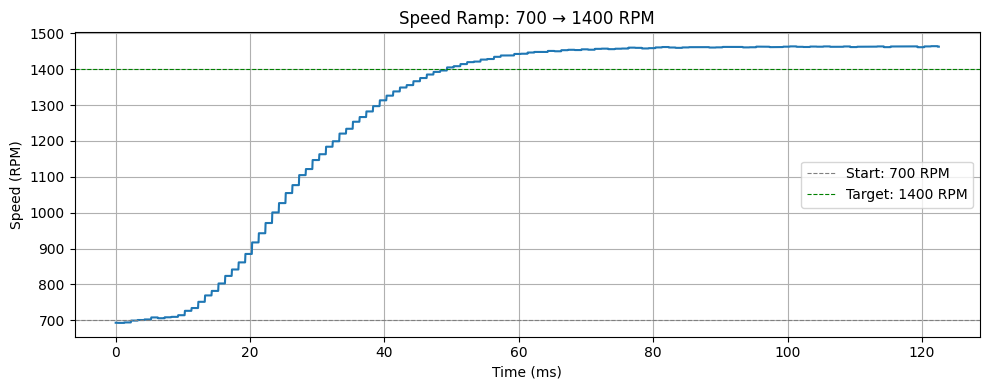

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ramp_time_ms, ramp_speed_rpm, color="tab:blue")
ax.axhline(TARGET_SPEED_1_RPM / 10, color="gray", linestyle="--", linewidth=0.8, label=f"Start: {TARGET_SPEED_1_RPM / 10:.0f} RPM")
ax.axhline(TARGET_SPEED_2_RPM / 10, color="green", linestyle="--", linewidth=0.8, label=f"Target: {TARGET_SPEED_2_RPM / 10:.0f} RPM")
ax.set_title(f"Speed Ramp: {TARGET_SPEED_1_RPM / 10:.0f} → {TARGET_SPEED_2_RPM / 10:.0f} RPM")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Speed (RPM)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 8 — Capture phase currents at 1400 RPM

In [11]:
time.sleep(2)   # let the motor settle at the new speed

# Switch scope channels back to phase currents
x2c_scope.clear_all_scope_channel()
x2c_scope.add_scope_channel(phase_current_a)
x2c_scope.add_scope_channel(phase_current_b)

x2c_scope.request_scope_data()
while not x2c_scope.is_scope_data_ready():
    time.sleep(0.1)

scope_data_2 = x2c_scope.get_scope_channel_data()
current_a_2 = np.array(scope_data_2["motor.iabc.a"])
current_b_2 = np.array(scope_data_2["motor.iabc.b"])

rms_a_2 = np.sqrt(np.mean(current_a_2 ** 2)) * 0.1
rms_b_2 = np.sqrt(np.mean(current_b_2 ** 2)) * 0.1
avg_current_2 = (rms_a_2 + rms_b_2) / 2

print(f"RMS current at {TARGET_SPEED_2_RPM / 10:.0f} RPM:  Ia={rms_a_2:.3f} A  Ib={rms_b_2:.3f} A  avg={avg_current_2:.3f} A")

RMS current at 1400 RPM:  Ia=25.176 A  Ib=22.583 A  avg=23.880 A


### Plot phase currents at 1400 RPM

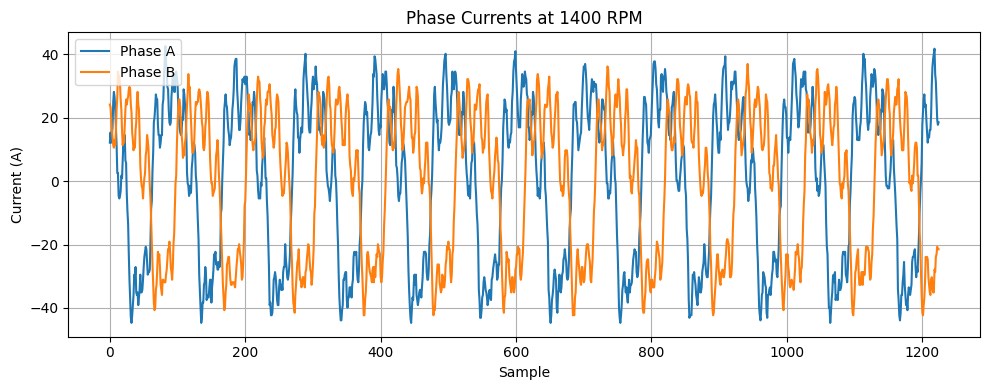

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(current_a_2 * 0.1, label="Phase A")
ax.plot(current_b_2 * 0.1, label="Phase B")
ax.set_title(f"Phase Currents at {TARGET_SPEED_2_RPM / 10:.0f} RPM")
ax.set_xlabel("Sample")
ax.set_ylabel("Current (A)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 9 — Summary

In [13]:
print("=" * 50)
print("HiL Test Summary")
print("=" * 50)
print(f"Time to reach {TARGET_SPEED_1_RPM / 10:.0f} RPM : {time_to_speed_1:.2f} s")
print(f"Avg RMS current @ {TARGET_SPEED_1_RPM / 10:.0f} RPM : {avg_current_1:.3f} A")
print(f"Speed ramp scope window    : {scope_window_ms:.1f} ms")
print(f"Avg RMS current @ {TARGET_SPEED_2_RPM / 10:.0f} RPM : {avg_current_2:.3f} A")

HiL Test Summary
Time to reach 700 RPM : 0.69 s
Avg RMS current @ 700 RPM : 18.213 A
Speed ramp scope window    : 122.5 ms
Avg RMS current @ 1400 RPM : 23.880 A


## 10 — Stop the motor and restore hardware UI

> **Always run this cell** before closing the notebook to return control to the hardware UI.

In [14]:
stop_motor_request.set_value(1)
print("Motor stopped")

hardware_ui_enabled.set_value(1)
print("Hardware UI re-enabled")

x2c_scope.disconnect()
print("Disconnected")

Motor stopped
Hardware UI re-enabled
Disconnected
